# Mini-Xception Training on FERPlus

This notebook trains the **Mini-Xception** model for facial emotion recognition
using the FERPlus dataset. It is designed to run with a Google Colab GPU kernel
via the VS Code Colab integration.

**Workflow:** Clone repository from GitHub, download FERPlus from Kaggle,
train and evaluate the model, save all outputs to `results/mini_xception/`.

**Important:** Make sure you select a GPU runtime
(Runtime > Change runtime type > T4 GPU).

## 1. Environment Setup

In [28]:
# GPU availability check
!nvidia-smi

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[WARNING] No GPU detected. Select a GPU runtime.")

Thu Mar 12 12:44:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             35W /   70W |     683MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
# Clone the repository from GitHub
import os

REPO_URL = (
    "https://github.com/aysenurhepguven0/"
    "adaptive-emotion-aware-virtual-interaction-system.git"
)
REPO_DIR = (
    "/content/"
    "adaptive-emotion-aware-virtual-interaction-system"
)

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repository already exists at {REPO_DIR}")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Repository already exists at /content/adaptive-emotion-aware-virtual-interaction-system
Working directory: /content/adaptive-emotion-aware-virtual-interaction-system


In [30]:
# Install project dependencies
%pip install -q -r requirements.txt
%pip install -q kagglehub

## 2. Configuration and Imports

In [31]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Ensure project root is on the import path
PROJECT_ROOT = Path(REPO_DIR).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.mini_xception import get_model

print(f"Project root: {PROJECT_ROOT}")
print("Imports complete.")

Project root: /content/adaptive-emotion-aware-virtual-interaction-system
Imports complete.


In [32]:
# --- Paths ---
DATASET_PATH = PROJECT_ROOT / "data" / "ferplus"
OUTPUT_DIR = PROJECT_ROOT / "results" / "mini_xception"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# --- Class filter ---
# FERPlus has 8 classes but Contempt, Disgust, and Fear have
# too few samples and hurt macro-weighted F1. Use 5 classes.
TARGET_CLASSES = ["angry", "happy", "neutral", "sad", "suprise"]

# --- Hyperparameters ---
NUM_EPOCHS = 30 if torch.cuda.is_available() else 10
BATCH_SIZE = 64 if torch.cuda.is_available() else 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
INPUT_SIZE = 48
EARLY_STOPPING_PATIENCE = 10

print(f"Device:     {DEVICE}")
print(f"Epochs:     {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Classes:    {TARGET_CLASSES}")
print(f"Dataset:    {DATASET_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Device:     cuda
Epochs:     30
Batch size: 64
Classes:    ['angry', 'happy', 'neutral', 'sad', 'suprise']
Dataset:    /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus
Output dir: /content/adaptive-emotion-aware-virtual-interaction-system/results/mini_xception


## 3. Dataset Preparation

In [33]:
# Download FERPlus from Kaggle if not already present
import kagglehub

splits_exist = (
    (DATASET_PATH / "train").exists()
    and (DATASET_PATH / "test").exists()
)

if not splits_exist:
    print("Downloading FERPlus dataset from Kaggle...")
    ferplus_download = kagglehub.dataset_download(
        "arnabkumarroy02/ferplus"
    )
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    !cp -r {ferplus_download}/* {DATASET_PATH}/
    print(f"Dataset saved to: {DATASET_PATH}")
else:
    print(f"Dataset already exists at: {DATASET_PATH}")

Dataset already exists at: /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus


In [34]:
# Verify dataset structure
print("FERPlus dataset structure:")
for split in ["train", "validation", "test"]:
    split_path = DATASET_PATH / split
    if split_path.exists():
        classes = sorted(
            d.name for d in split_path.iterdir() if d.is_dir()
        )
        total = sum(
            len(list((split_path / c).iterdir()))
            for c in classes
        )
        print(
            f"  {split:12s}: {total:>6,} images, "
            f"{len(classes)} classes"
        )
    else:
        print(f"  {split:12s}: NOT FOUND")

FERPlus dataset structure:
  train       : 66,379 images, 8 classes
  validation  :  8,341 images, 8 classes
  test        :  3,573 images, 8 classes


In [35]:
# Build transforms and create DataLoaders
# FERPlus images are 48x48 grayscale; convert to 3-channel
# to match the model's default input channels.
train_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1, contrast=0.1, saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def filter_classes(dataset, target_classes):
    """Keep only samples belonging to target_classes
    and remap labels to 0..len(target_classes)-1."""
    keep_indices = {
        dataset.class_to_idx[c] for c in target_classes
        if c in dataset.class_to_idx
    }
    # New sequential mapping: sorted original indices -> 0,1,2,...
    idx_map = {
        old: new
        for new, old in enumerate(sorted(keep_indices))
    }
    dataset.samples = [
        (path, idx_map[label])
        for path, label in dataset.samples
        if label in idx_map
    ]
    dataset.targets = [s[1] for s in dataset.samples]
    dataset.classes = [
        c for c in dataset.classes
        if dataset.class_to_idx.get(c) in keep_indices
    ]
    dataset.class_to_idx = {
        c: i for i, c in enumerate(dataset.classes)
    }
    return dataset


train_dataset = datasets.ImageFolder(
    DATASET_PATH / "train", transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    DATASET_PATH / "validation", transform=eval_transforms
)
test_dataset = datasets.ImageFolder(
    DATASET_PATH / "test", transform=eval_transforms
)

# Filter to 5 target classes
filter_classes(train_dataset, TARGET_CLASSES)
filter_classes(val_dataset, TARGET_CLASSES)
filter_classes(test_dataset, TARGET_CLASSES)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(
    f"Train: {len(train_dataset):,} | "
    f"Val: {len(val_dataset):,} | "
    f"Test: {len(test_dataset):,}"
)

Classes (5): ['angry', 'happy', 'neutral', 'sad', 'suprise']
Train: 42,379 | Val: 5,341 | Test: 3,424


## 4. Model Initialization

In [36]:
model = get_model(
    num_classes=NUM_CLASSES, in_channels=3, dropout=0.5
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Mini-Xception")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Number of classes:    {NUM_CLASSES}")
print(f"  Input channels:       3")

Mini-Xception
  Total parameters:     84,741
  Trainable parameters: 84,741
  Number of classes:    5
  Input channels:       3


## 5. Training

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
}
best_val_acc = 0.0
best_model_path = OUTPUT_DIR / "best_mini_xception.pth"
patience_counter = 0

print(f"Training Mini-Xception for {NUM_EPOCHS} epochs")
print(f"  Device: {DEVICE} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    # -- Training phase --
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * labels.size(0)
        train_correct += (
            (outputs.argmax(dim=1) == labels).sum().item()
        )
        train_total += labels.size(0)

    # -- Validation phase --
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            val_correct += (
                (outputs.argmax(dim=1) == labels).sum().item()
            )
            val_total += labels.size(0)

    # -- Epoch metrics --
    ep_train_loss = train_loss / train_total
    ep_train_acc = train_correct / train_total
    ep_val_loss = val_loss / val_total
    ep_val_acc = val_correct / val_total
    elapsed = time.time() - start

    history["train_loss"].append(ep_train_loss)
    history["train_acc"].append(ep_train_acc)
    history["val_loss"].append(ep_val_loss)
    history["val_acc"].append(ep_val_acc)

    # -- Checkpoint best model --
    marker = ""
    if ep_val_acc > best_val_acc:
        best_val_acc = ep_val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        marker = " [BEST]"
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:>2}/{NUM_EPOCHS} ({elapsed:.0f}s) | "
        f"Train {ep_train_loss:.4f} / {ep_train_acc:.2%} | "
        f"Val {ep_val_loss:.4f} / {ep_val_acc:.2%}{marker}"
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping at epoch {epoch} "
            f"(no improvement for {EARLY_STOPPING_PATIENCE} epochs)"
        )
        break

print("=" * 70)
print(f"Best validation accuracy: {best_val_acc:.2%}")
print(f"Best model saved to: {best_model_path}")

Training Mini-Xception for 30 epochs
  Device: cuda | Batch: 64 | LR: 0.001
Epoch  1/30 (33s) | Train 1.3581 / 43.22% | Val 1.0881 / 56.26% [BEST]
Epoch  2/30 (32s) | Train 1.0105 / 59.76% | Val 0.8786 / 65.98% [BEST]
Epoch  3/30 (33s) | Train 0.8747 / 65.52% | Val 0.8411 / 67.40% [BEST]
Epoch  4/30 (33s) | Train 0.8019 / 68.82% | Val 0.7942 / 70.19% [BEST]
Epoch  5/30 (33s) | Train 0.7519 / 70.75% | Val 0.7119 / 72.87% [BEST]
Epoch  6/30 (32s) | Train 0.7101 / 72.58% | Val 0.7355 / 72.83%
Epoch  7/30 (32s) | Train 0.6777 / 73.93% | Val 0.6513 / 74.99% [BEST]
Epoch  8/30 (32s) | Train 0.6521 / 74.74% | Val 0.6575 / 75.32% [BEST]
Epoch  9/30 (32s) | Train 0.6319 / 75.70% | Val 0.7295 / 73.04%
Epoch 10/30 (32s) | Train 0.6081 / 76.76% | Val 0.6632 / 75.66% [BEST]
Epoch 11/30 (32s) | Train 0.5939 / 77.21% | Val 0.6671 / 74.84%
Epoch 12/30 (32s) | Train 0.5766 / 77.77% | Val 0.6512 / 76.00% [BEST]
Epoch 13/30 (32s) | Train 0.5633 / 78.30% | Val 0.6054 / 77.21% [BEST]
Epoch 14/30 (32s) | Tr

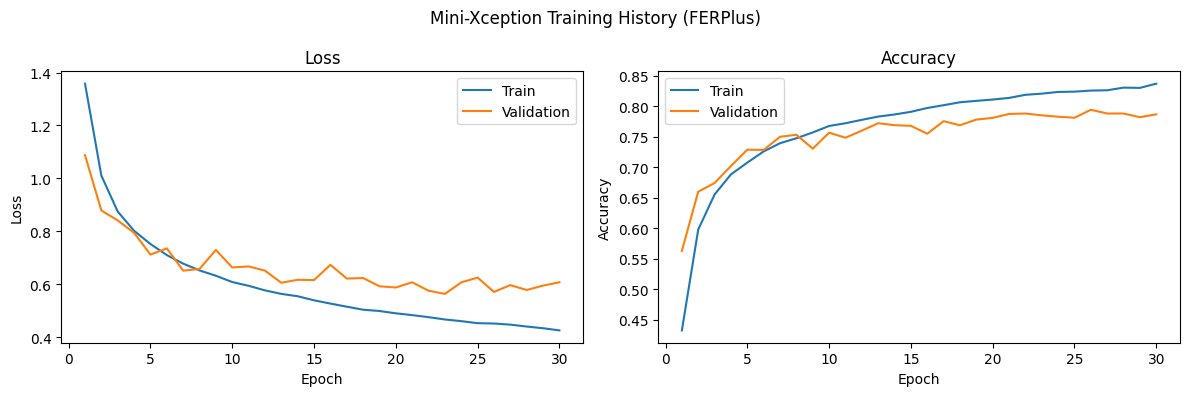

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/mini_xception/training_history.png


In [38]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

fig.suptitle("Mini-Xception Training History (FERPlus)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_history.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR / 'training_history.png'}")

## 6. Evaluation

In [39]:
# Load the best checkpoint and evaluate on the test set
model.load_state_dict(
    torch.load(best_model_path, map_location=DEVICE)
)
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())

test_acc = sum(
    t == p for t, p in zip(y_true, y_pred)
) / len(y_true)

print(f"Test Accuracy: {test_acc:.2%}")
print()
report_text = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES
)
print(report_text)

Test Accuracy: 77.19%

              precision    recall  f1-score   support

       angry       0.60      0.77      0.68       322
       happy       0.91      0.82      0.86       929
     neutral       0.77      0.82      0.79      1274
         sad       0.60      0.48      0.54       449
     suprise       0.81      0.83      0.82       450

    accuracy                           0.77      3424
   macro avg       0.74      0.74      0.74      3424
weighted avg       0.78      0.77      0.77      3424



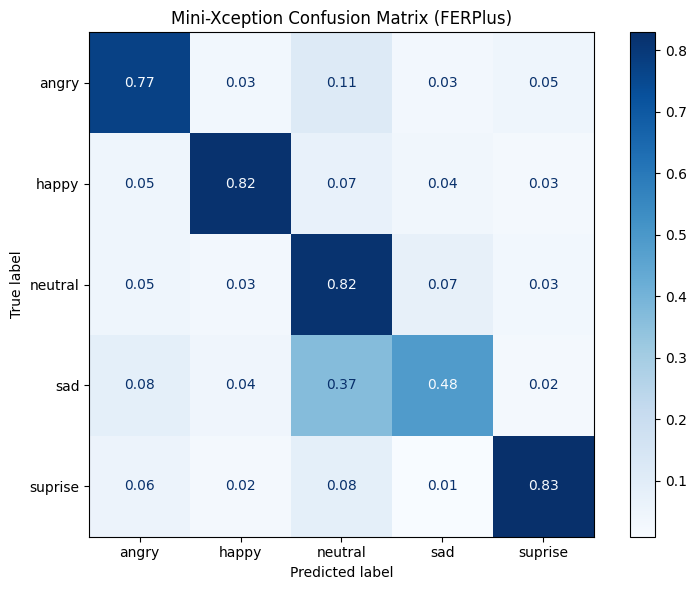

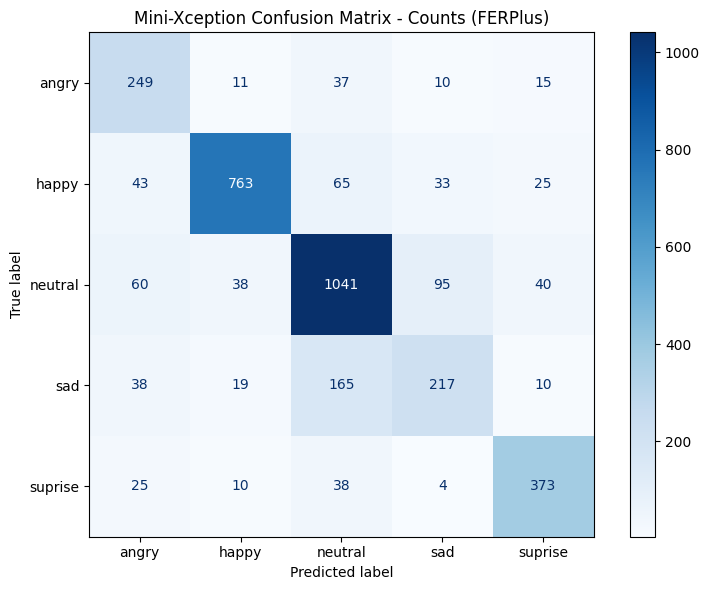

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/mini_xception/confusion_matrix.png
Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/mini_xception/confusion_matrix_counts.png


In [40]:
# Confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=CLASS_NAMES
)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=True)
ax.set_title("Mini-Xception Confusion Matrix (FERPlus)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# Confusion matrix (raw counts)
cm_counts = confusion_matrix(y_true, y_pred)
fig2, ax2 = plt.subplots(figsize=(8, 6))
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_counts, display_labels=CLASS_NAMES
)
disp2.plot(ax=ax2, cmap="Blues", values_format="d", colorbar=True)
ax2.set_title("Mini-Xception Confusion Matrix - Counts (FERPlus)")
fig2.tight_layout()
fig2.savefig(
    OUTPUT_DIR / "confusion_matrix_counts.png", dpi=150
)
plt.show()

print(f"Saved: {OUTPUT_DIR / 'confusion_matrix.png'}")
print(f"Saved: {OUTPUT_DIR / 'confusion_matrix_counts.png'}")

## 7. Save Outputs

In [41]:
# Save training history as JSON
history_path = OUTPUT_DIR / "training_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)

# Save evaluation summary as JSON
report_dict = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
)
eval_summary = {
    "model": "mini_xception",
    "dataset": "ferplus",
    "num_classes": NUM_CLASSES,
    "class_names": list(CLASS_NAMES),
    "epochs_trained": len(history["train_loss"]),
    "best_val_accuracy": best_val_acc,
    "test_accuracy": test_acc,
    "classification_report": report_dict,
}
eval_path = OUTPUT_DIR / "evaluation_summary.json"
with open(eval_path, "w") as f:
    json.dump(eval_summary, f, indent=2)

# List all saved outputs
print(f"All outputs saved to: {OUTPUT_DIR}")
print("-" * 50)
for p in sorted(OUTPUT_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:40s} {size_kb:>8.1f} KB")

All outputs saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/mini_xception
--------------------------------------------------
  best_mini_xception.pth                      373.8 KB
  confusion_matrix.png                         70.6 KB
  confusion_matrix_counts.png                  63.0 KB
  evaluation_summary.json                       1.4 KB
  training_history.json                         2.9 KB
  training_history.png                         83.4 KB


## Summary

**Outputs saved to `results/mini_xception/`:**

| File | Description |
|------|-------------|
| `best_mini_xception.pth` | Best model checkpoint (by validation accuracy) |
| `training_history.json` | Per-epoch train/val loss and accuracy |
| `training_history.png` | Loss and accuracy curves |
| `evaluation_summary.json` | Test accuracy and per-class classification report |
| `confusion_matrix.png` | Normalized confusion matrix |
| `confusion_matrix_counts.png` | Raw count confusion matrix |